# Foundations of Digital Image Analysis


This notebook demonstrates the foundational principles of digital image representation. By treating images as multi-channel tensors, we perform spectral decomposition to analyze individual color distributions. Understanding these low-level signal properties is essential for designing robust feature extraction pipelines in high-level Computer Vision tasks.

In [ ]:
pip install opencv-python

In [ ]:
import cv2

## Uploading the image

Image read successfully.


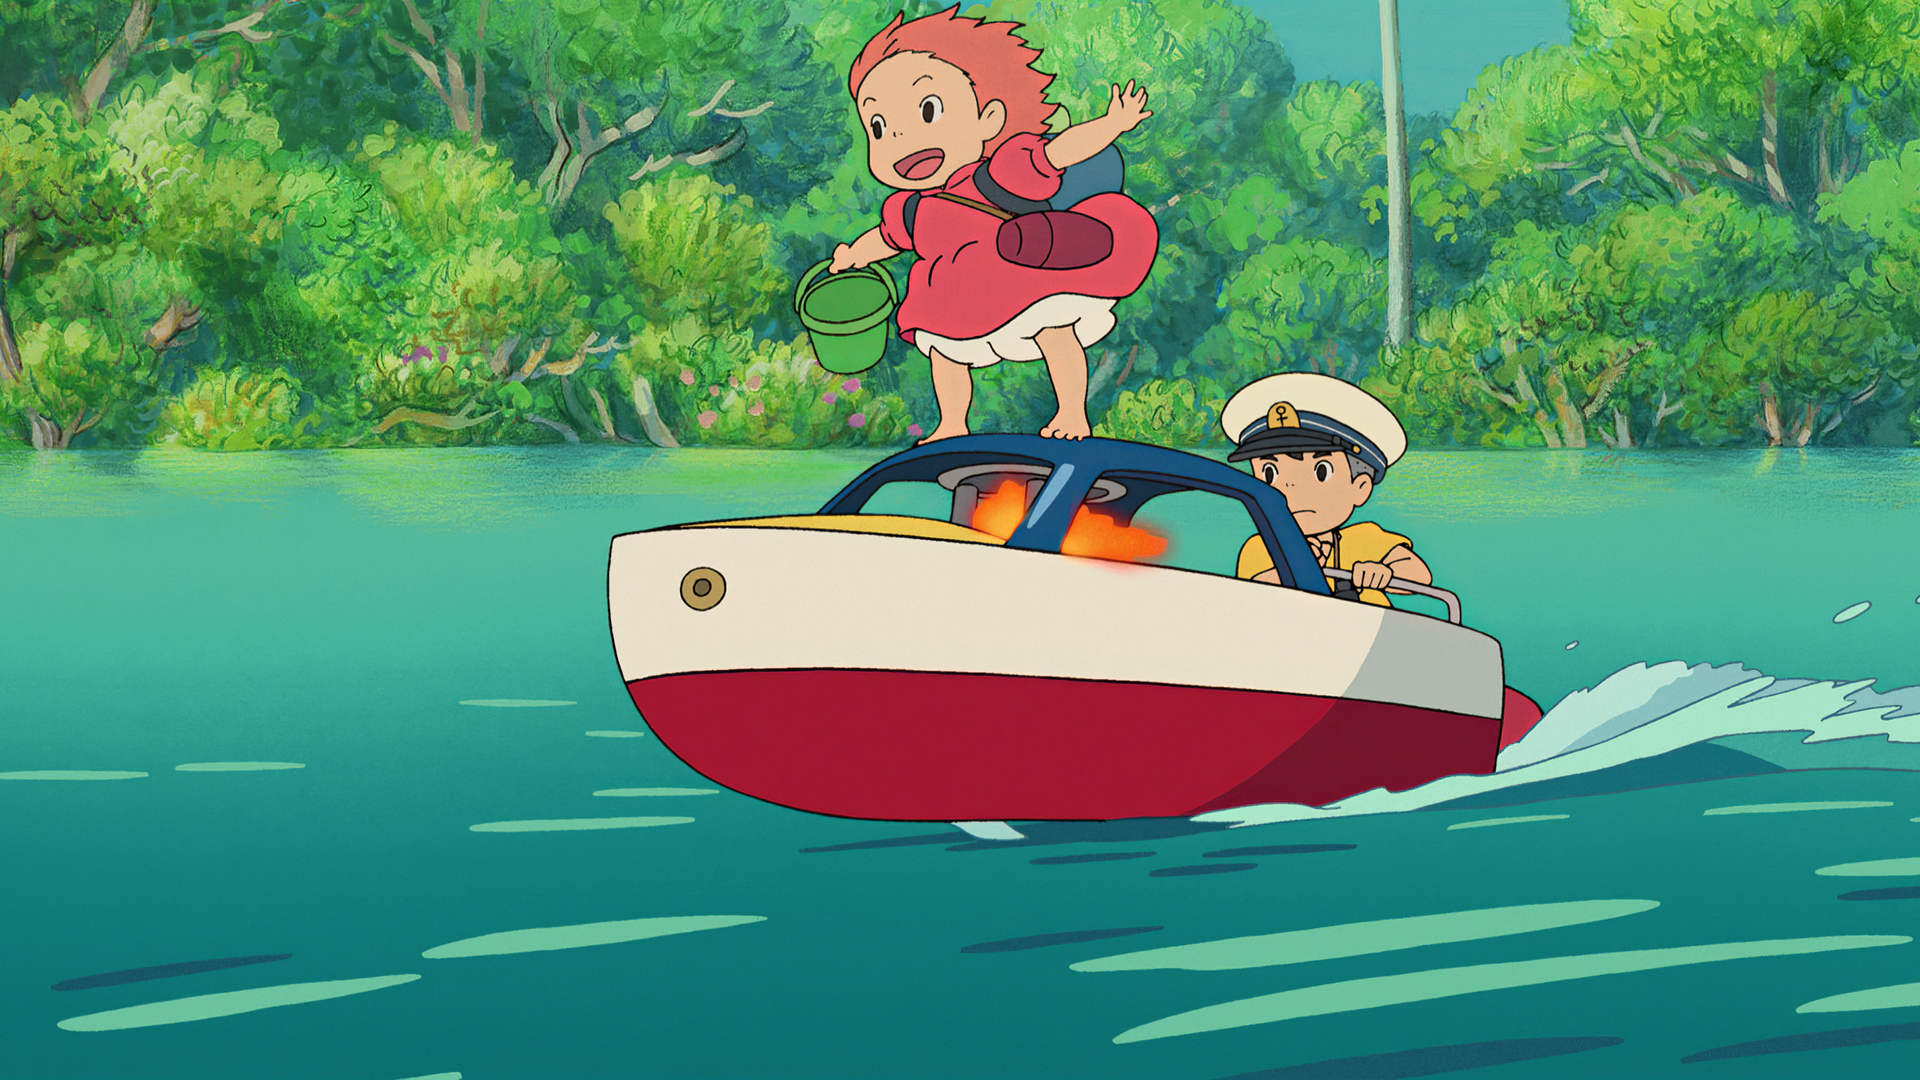

In [ ]:

from google.colab.patches import cv2_imshow
import cv2

# Read the image
image = cv2.imread("/content/26.png")

# Check if the image was successfully read
if image is not None:
    print("Image read successfully.")
    # Display the image
    cv2_imshow(image)
else:
    print("Failed to read image.")

In [ ]:
height, width, channels = image.shape

# Display the dimensions
print(f"Image Dimensions: Width = {width}, Height = {height}, Channels = {channels}")

Image Dimensions: Width = 1920, Height = 1080, Channels = 3


In [ ]:
# Specify the path to save the TIFF file
tiff_path = '/content/03.tiff'

# Save the image as TIFF
#cv2.imwrite(tiff_path, image, [cv2.IMWRITE_TIFF_COMPRESSION, cv2.IMWRITE_TIFF_RESUNIT])
cv2.imwrite(tiff_path, image)

True

In [ ]:
jpeg_path = '/content/image.jpg'

# Save the image as JPEG
cv2.imwrite(jpeg_path, image)

True

### Spectral Decomposition (BGR/RGB)
Digital images are represented as multi-channel tensors. Here, we decompose the image into its constituent Blue, Green, and Red channels.

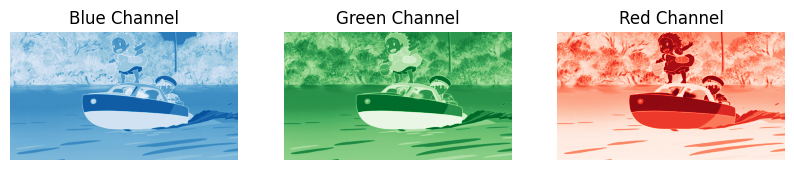

In [ ]:

import matplotlib.pyplot as plt
blue_channel, green_channel, red_channel = cv2.split(image)

# Display each channel separately
plt.figure(figsize=(10, 4))

plt.subplot(131)
plt.imshow(blue_channel, cmap='Blues')
plt.title('Blue Channel')
plt.axis('off')

plt.subplot(132)
plt.imshow(green_channel, cmap='Greens')
plt.title('Green Channel')
plt.axis('off')

plt.subplot(133)
plt.imshow(red_channel, cmap='Reds')
plt.title('Red Channel')
plt.axis('off')

plt.show()

We reconstruct the image from those channels

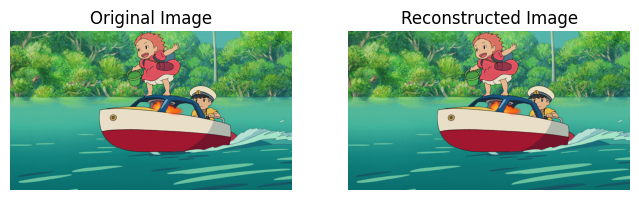

In [ ]:
reconstructed_image = cv2.merge([blue_channel, green_channel, red_channel])

# Display the original and reconstructed images
plt.figure(figsize=(8, 4))

plt.subplot(121)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(122)
plt.imshow(cv2.cvtColor(reconstructed_image, cv2.COLOR_BGR2RGB))
plt.title('Reconstructed Image')
plt.axis('off')

plt.show()

### Dimensionality Reduction: Grayscale and Thresholding

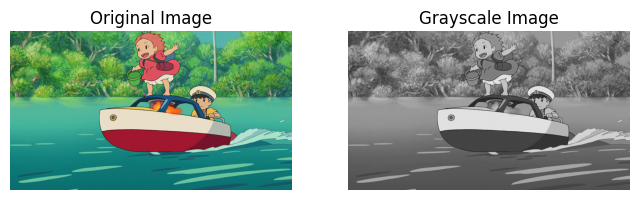

In [ ]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display the original and grayscale images
plt.figure(figsize=(8, 4))

plt.subplot(121)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(122)
plt.imshow(gray_image, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.show()

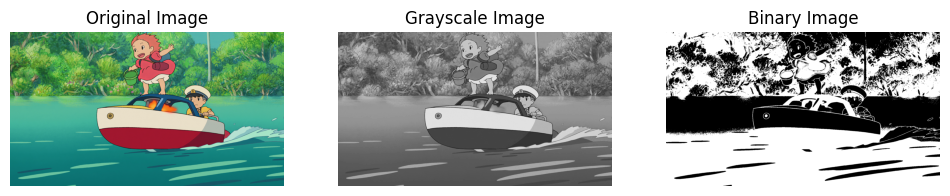

In [ ]:
threshold_value = 128

# Apply binary thresholding
_, binary_image = cv2.threshold(gray_image, threshold_value, 255, cv2.THRESH_BINARY)

# Display the original, grayscale, and binary images
plt.figure(figsize=(12, 4))

plt.subplot(131)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(132)
plt.imshow(gray_image, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.subplot(133)
plt.imshow(binary_image, cmap='binary')
plt.title('Binary Image')
plt.axis('off')

plt.show()

### Histogram Analysis

<Figure size 1500x500 with 0 Axes>

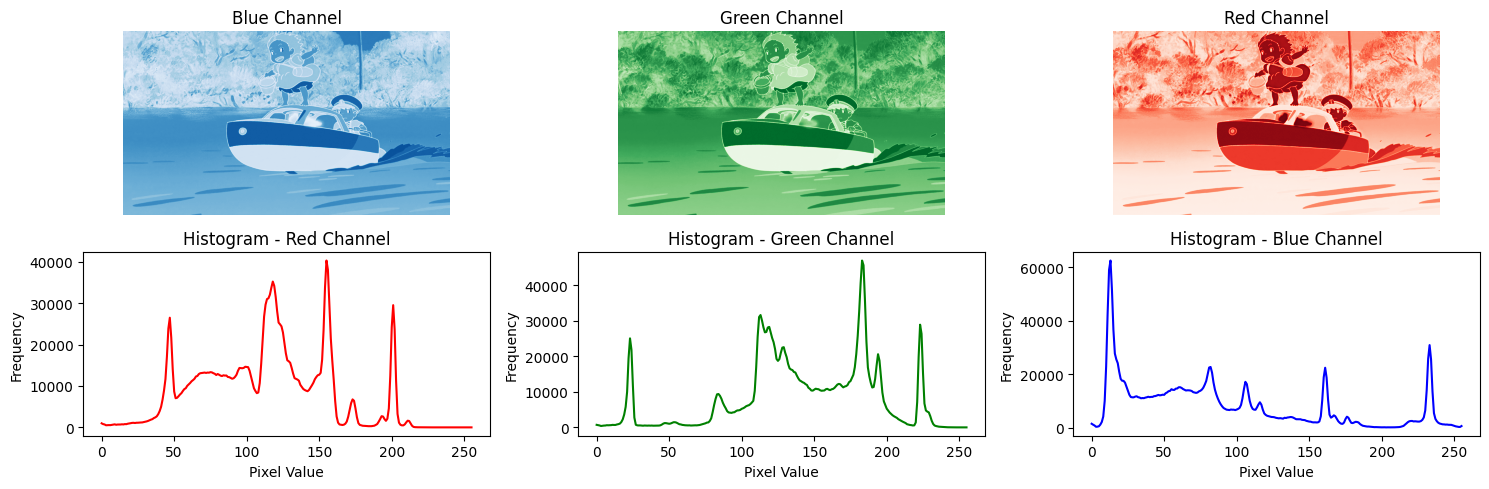

In [ ]:
plt.figure(figsize=(15, 5))

def plot_histogram(image, title, color):
    histogram = cv2.calcHist([image], [0], None, [256], [0, 256])
    plt.plot(histogram, color=color)
    plt.title(title)
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')

# Plot histograms for each channel
plt.figure(figsize=(15, 5))


plt.subplot(233)
plt.imshow(red_channel, cmap='Reds')
plt.title('Red Channel')
plt.axis('off')

plt.subplot(232)
plt.imshow(green_channel, cmap='Greens')
plt.title('Green Channel')
plt.axis('off')

plt.subplot(231)
plt.imshow(blue_channel, cmap='Blues')
plt.title('Blue Channel')
plt.axis('off')


# Plot histograms for each channel separately
for i, color in enumerate(['red', 'green', 'blue']):
    plt.subplot(2, 3, i+4)
    plot_histogram(image[:, :, i], f'Histogram - {color.capitalize()} Channel', color)

plt.tight_layout()
plt.show()

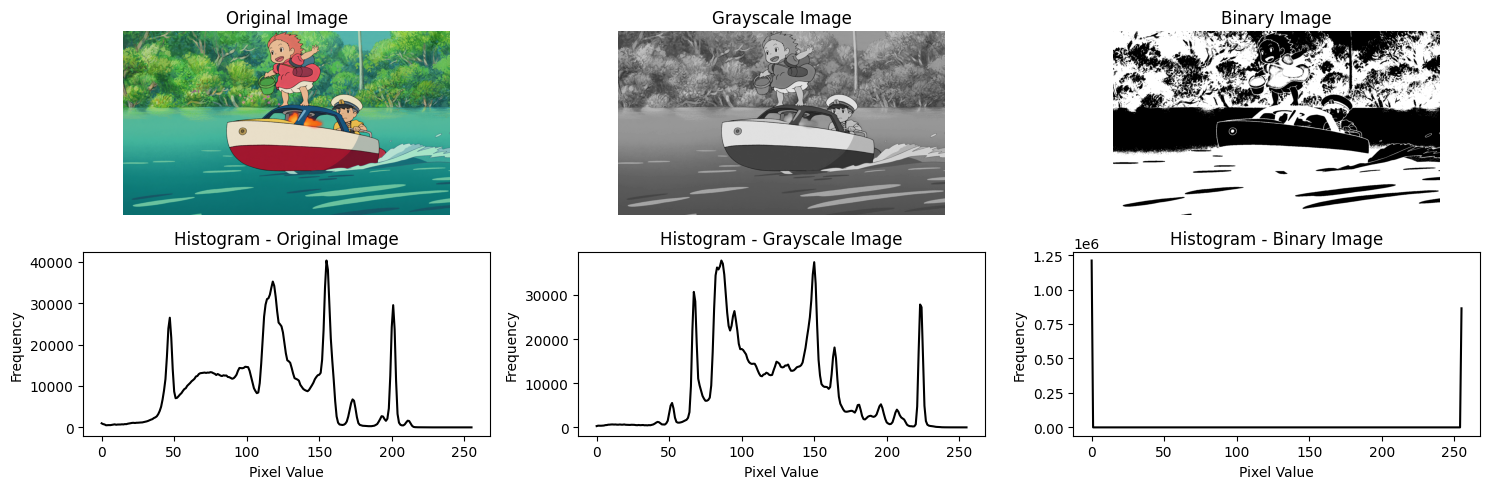

In [ ]:
plt.figure(figsize=(15, 5))

# Original Image and Histogram
plt.subplot(231)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(234)
plot_histogram(image, 'Histogram - Original Image', 'black')

# Grayscale Image and Histogram
plt.subplot(232)
plt.imshow(gray_image, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.subplot(235)
plot_histogram(gray_image, 'Histogram - Grayscale Image', 'black')

# Binary Image and Histogram
plt.subplot(233)
plt.imshow(binary_image, cmap='binary')
plt.title('Binary Image')
plt.axis('off')

plt.subplot(236)
plot_histogram(binary_image, 'Histogram - Binary Image', 'black')

plt.tight_layout()
plt.show()

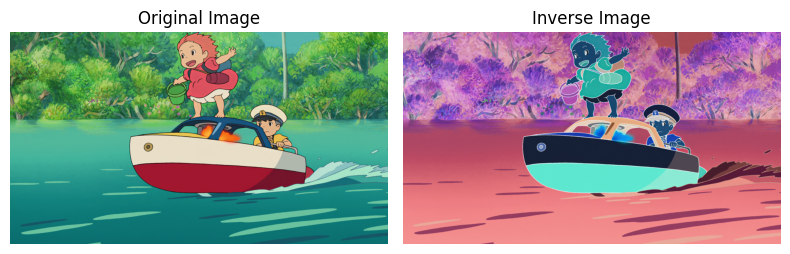

In [ ]:


# Calculate the inverse of the color image
inverse_image = 255 - image

# Display the original and inverse color images
plt.figure(figsize=(8, 4))

plt.subplot(121)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(122)
plt.imshow(cv2.cvtColor(inverse_image, cv2.COLOR_BGR2RGB))
plt.title('Inverse Image')
plt.axis('off')

plt.tight_layout()
plt.show()

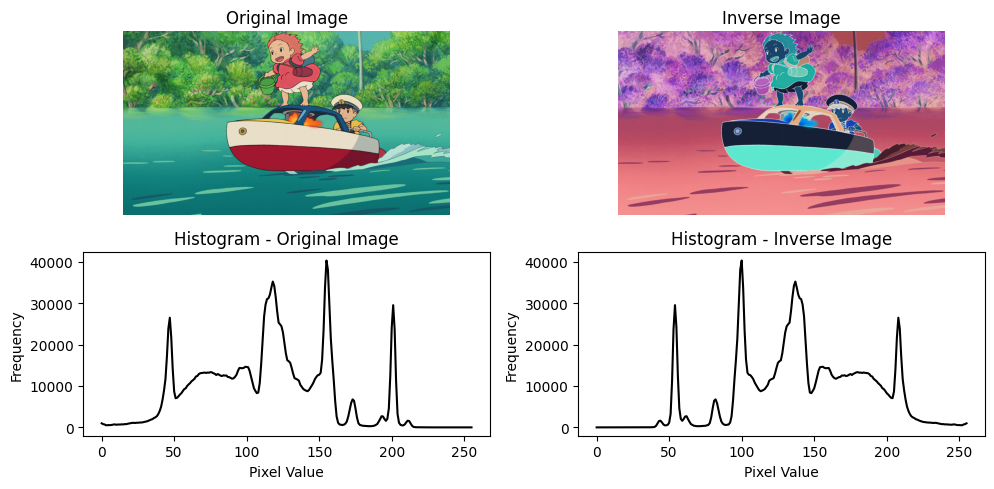

In [ ]:
# Plot histograms for the original and inverse color images
plt.figure(figsize=(15, 5))

# Original Image and Histogram
plt.subplot(231)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(234)
plot_histogram(image, 'Histogram - Original Image', 'black')

# Inverse Image and Histogram
plt.subplot(232)
plt.imshow(cv2.cvtColor(inverse_image, cv2.COLOR_BGR2RGB))
plt.title('Inverse Image')
plt.axis('off')

plt.subplot(235)
plot_histogram(inverse_image, 'Histogram - Inverse Image', 'black')

plt.tight_layout()
plt.show()

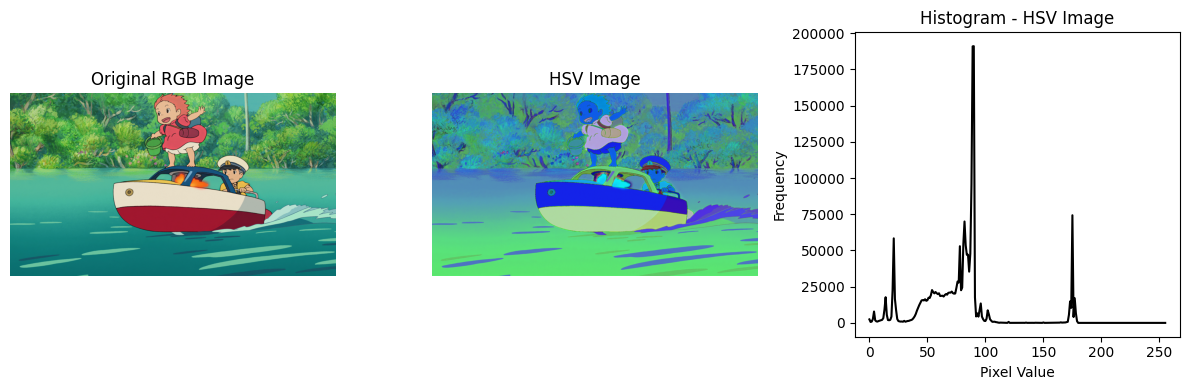

In [ ]:
hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Display the original and HSV images
plt.figure(figsize=(12, 4))

plt.subplot(131)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original RGB Image')
plt.axis('off')

plt.subplot(132)
plt.imshow(hsv_image)
plt.title('HSV Image')
plt.axis('off')

# Plot histograms for each channel of the HSV image
plt.subplot(133)
plot_histogram(hsv_image, 'Histogram - HSV Image', 'black')

plt.tight_layout()
plt.show()


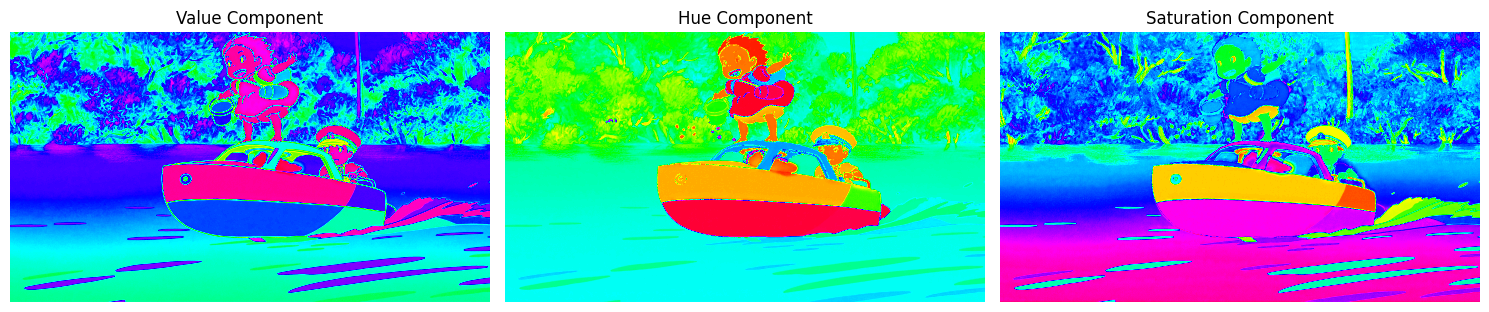

In [ ]:

# Split the HSV image into its components
h, s, v = cv2.split(hsv_image)

# Display the original RGB and HSV images
plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original RGB Image')
plt.axis('off')

# Display the individual HSV components
plt.subplot(132)
plt.imshow(h, cmap='hsv', vmin=0, vmax=179)
plt.title('Hue Component')
plt.axis('off')

plt.subplot(133)
plt.imshow(s, cmap='hsv', vmin=0, vmax=255)
plt.title('Saturation Component')
plt.axis('off')

plt.subplot(131)
plt.imshow(v, cmap='hsv', vmin=0, vmax=255)
plt.title('Value Component')
plt.axis('off')

plt.tight_layout()
plt.show()

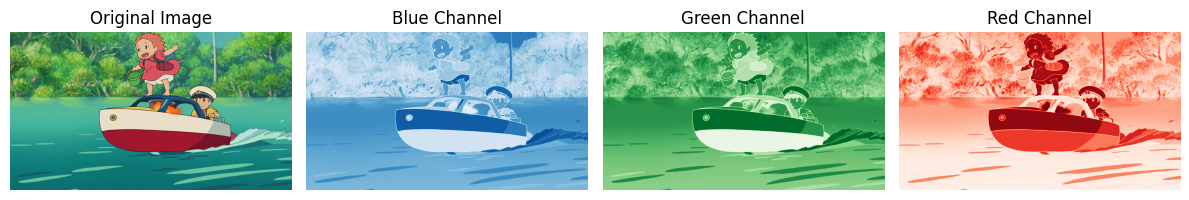

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Specify the path to your PNG image
image_path = '/content/03.png'

# Read the image using cv2.imread()
image = cv2.imread(image_path)

# Split the image into its RGB components using NumPy slicing
blue_channel = image[:, :, 0]  # Blue channel
green_channel = image[:, :, 1]  # Green channel
red_channel = image[:, :, 2]  # Red channel

# Display the original image and individual RGB components
plt.figure(figsize=(12, 4))

plt.subplot(141)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(142)
plt.imshow(blue_channel, cmap='Blues')
plt.title('Blue Channel')
plt.axis('off')

plt.subplot(143)
plt.imshow(green_channel, cmap='Greens')
plt.title('Green Channel')
plt.axis('off')

plt.subplot(144)
plt.imshow(red_channel, cmap='Reds')
plt.title('Red Channel')
plt.axis('off')

plt.tight_layout()
plt.show()
